# Análisis ConnectaTel

Como **analista de datos**, tu objetivo es evaluar el **comportamiento de los clientes** de una empresa de telecomunicaciones en Latinoamérica, ConnectaTel. 

Trabajaremos con información registrada **hasta el año 2024**, lo cual permitirá analizar el comportamiento del negocio dentro de ese periodo.

Para ello trabajarás con tres datasets:  

- **plans.csv** → información de los planes actuales (precio, minutos incluidos, GB incluidos, costo por extra)  
- **users.csv** → información de los clientes (edad, ciudad, fecha de registro, plan, churn)  
- **usage.csv** → detalle del **uso real** de los servicios (llamadas y mensajes)  

Deberás **explorar**, **limpiar** y **analizar** estos datos para construir un **perfil estadístico** de los clientes, detectar **comportamientos atípicos** y crear **segmentos de clientes**.  

Este análisis te permitirá **identificar patrones de consumo**, **diseñar estrategias de retención** y **sugerir mejoras en los planes** ofrecidos por la empresa.

> 💡 Antes de empezar, recuerda pensar de forma **programática**: ¿qué pasos necesitas? ¿En qué orden? ¿Qué quieres medir y por qué?


--- 
## 🧩 Paso 1: Cargar y explorar

Antes de limpiar o combinar los datos, es necesario **familiarizarte con la estructura de los tres datasets**.  
En esta etapa, validarás que los archivos se carguen correctamente, conocerás sus columnas y tipos de datos, y detectarás posibles inconsistencias.

### 1.1 Carga de datos y vista rápida

**🎯 Objetivo:**  
Tener los **3 datasets listos en memoria**, entender su contenido y realizar una revisión preliminar.

**Instrucciones:**  
- Importa las librerías necesarias (por ejemplo `pandas`, `seaborn`, `matplotlib.pyplot`)
- Carga los archivos CSV usando `pd.read_csv()`:
  - **`/datasets/plans.csv`**  
  - **`/datasets/users_latam.csv`**  
  - **`/datasets/usage.csv`**  
- Guarda los DataFrames en las variables: `plans`, `users`, `usage`.  
- Muestra las primeras filas de cada DataFrame usando `.head()`.


In [4]:
# importar librerías
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

In [5]:
# cargar archivos
plans = pd.read_csv('/datasets/plans.csv')
users = pd.read_csv('/datasets/users_latam.csv')
usage = pd.read_csv('/datasets/usage.csv')

In [6]:
# mostrar las primeras 5 filas de plans
plans.head(5)

,plan_name,messages_included,gb_per_month,minutes_included,usd_monthly_pay,usd_per_gb,usd_per_message,usd_per_minute
0,Basico,100,5,100,12,1.2,0.08,0.10
1,Premium,500,20,600,25,1.0,0.05,0.07


In [7]:
# mostrar las primeras 5 filas de users
users.head(5)

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date
0,10000,Carlos,Garcia,38,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN
1,10001,Mateo,Torres,53,?,2022-01-01 06:34:17.914478619,Basico,NaN
2,10002,Sofia,Ramirez,57,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN
3,10003,Mateo,Ramirez,69,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN
4,10004,Mateo,Torres,63,GDL,2022-01-02 02:17:11.657914478,Basico,NaN


In [8]:
# mostrar las primeras 5 filas de usage
usage.head(5)

,id,user_id,type,date,duration,length
0,1,10332,call,2024-01-01 00:00:00.000000000,0.09,NaN
1,2,11458,text,2024-01-01 00:06:30.969774244,NaN,39.0
2,3,11777,text,2024-01-01 00:13:01.939548488,NaN,36.0
3,4,10682,call,2024-01-01 00:19:32.909322733,1.53,NaN
4,5,12742,call,2024-01-01 00:26:03.879096977,4.84,NaN


**Tip:** Si no usas `print()` la tabla se vera mejor.

### 1.2 Exploración de la estructura de los datasets

**🎯 Objetivo:**  
Conocer la **estructura de cada dataset**, revisar cuántas filas y columnas tienen, identificar los **tipos de datos** de cada columna y detectar posibles **inconsistencias o valores nulos** antes de iniciar el análisis.

**Instrucciones:**  
- Revisa el **número de filas y columnas** de cada dataset usando `.shape`.  
- Usa `.info()` en cada DataFrame para obtener un **resumen completo** de columnas, tipos de datos y valores no nulos.  

In [9]:
# revisar el número de filas y columnas de cada dataset
print("plans", plans.shape)
print("users", users.shape)
print("usage", usage.shape)

plans (2, 8)
users (4000, 8)
usage (40000, 6)


In [10]:
# inspección de plans con .info()
plans.info

<bound method DataFrame.info of   plan_name  messages_included  gb_per_month  minutes_included  \
0    Basico                100             5               100   
1   Premium                500            20               600   

   usd_monthly_pay  usd_per_gb  usd_per_message  usd_per_minute  
0               12         1.2             0.08            0.10  
1               25         1.0             0.05            0.07  >

In [11]:
# inspección de users con .info()
users.info

<bound method DataFrame.info of       user_id first_name last_name  age      city  \
0       10000     Carlos    Garcia   38  Medellín   
1       10001      Mateo    Torres   53         ?   
2       10002      Sofia   Ramirez   57      CDMX   
3       10003      Mateo   Ramirez   69    Bogotá   
4       10004      Mateo    Torres   63       GDL   
...       ...        ...       ...  ...       ...   
3995    13995        Ana     Lopez   60  Medellín   
3996    13996     Carlos   Ramirez   24  Medellín   
3997    13997        Ana     Lopez   58    Bogotá   
3998    13998    Mariana     Lopez   57    Bogotá   
3999    13999        Ana     Lopez   20    Bogotá   

                           reg_date     plan churn_date  
0     2022-01-01 00:00:00.000000000   Basico        NaN  
1     2022-01-01 06:34:17.914478619   Basico        NaN  
2     2022-01-01 13:08:35.828957239   Basico        NaN  
3     2022-01-01 19:42:53.743435858  Premium        NaN  
4     2022-01-02 02:17:11.657914478   Bas

In [12]:
# inspección de usage con .info()
usage.info

<bound method DataFrame.info of           id  user_id  type                           date  duration  length
0          1    10332  call  2024-01-01 00:00:00.000000000      0.09     NaN
1          2    11458  text  2024-01-01 00:06:30.969774244       NaN    39.0
2          3    11777  text  2024-01-01 00:13:01.939548488       NaN    36.0
3          4    10682  call  2024-01-01 00:19:32.909322733      1.53     NaN
4          5    12742  call  2024-01-01 00:26:03.879096977      4.84     NaN
...      ...      ...   ...                            ...       ...     ...
39995  39996    13497  call  2024-06-29 23:33:56.120903022      5.75     NaN
39996  39997    10941  call  2024-06-29 23:40:27.090677266      3.06     NaN
39997  39998    13038  call  2024-06-29 23:46:58.060451510      8.74     NaN
39998  39999    10863  text  2024-06-29 23:53:29.030225754       NaN    43.0
39999  40000    10759  call  2024-06-30 00:00:00.000000000      1.32     NaN

[40000 rows x 6 columns]>

---

## 🧩Paso 2: Identificación de problemas de calidad de datos

### 2.1 Revisión de valores nulos

**🎯 Objetivo:**  
Detectar la presencia y magnitud de valores faltantes para evaluar si afectan el análisis o requieren imputación/eliminación.

**Instrucciones:**  
- Cuenta valores nulos por columna para cada dataset.
- Calcula la proporción de nulos por columna para cada dataset.

El dataset `plans` solamente tiene 2 renglones y se puede observar que no tiene ausentes, por ello no necesita exploración adicional.

<br>
<details>
<summary>Haz clic para ver la pista</summary>
Usa `.isna().sum()` para contar valores nulos y usa `.isna().mean()` para calcular la proporción.

In [13]:
# cantidad de nulos para users
print(users.isna().sum())
print(users.isna().mean())

user_id          0
first_name       0
last_name        0
age              0
city           469
reg_date         0
plan             0
churn_date    3534
dtype: int64
user_id       0.00000
first_name    0.00000
last_name     0.00000
age           0.00000
city          0.11725
reg_date      0.00000
plan          0.00000
churn_date    0.88350
dtype: float64


In [14]:
# cantidad de nulos para usage
print(usage.isna().sum())
print(usage.isna().mean())

id              0
user_id         0
type            0
date           50
duration    22076
length      17896
dtype: int64
id          0.00000
user_id     0.00000
type        0.00000
date        0.00125
duration    0.55190
length      0.44740
dtype: float64


✍️ **Comentario**: Haz doble clic en este bloque y escribe tu diagnóstico al final del bloque. Incluye qué ves y que acción recomendarías para cada caso.

💡 **Nota:** Justifica tus decisiones brevemente (1 línea por caso).
* Hint:
 - Si una columna tiene **más del 80–90% de nulos**, normalmente se **ignora o elimina**.  
 - Si tiene **entre 5% y 30%**, generalmente se **investiga para imputar o dejar como nulos**.  
 - Si es **menor al 5%**, suele ser un caso simple de imputación o dejar como nulos. 
 
 ---

**Valores nulos**  
- ¿Qué columnas tienen valores faltantes y en qué proporción?
Para Users, tenemos valores faltantes en las columnas "City" con un 11% y "Churn_date" con un 88%

Para Usage, tenemos valores faltantes en las columnas "duration" con un 55%, "lenght" con un 44% y "date" con un 0,1%

- Indica qué harías: ¿imputar, eliminar, ignorar?
  
Para users, la columna "City" necesita revisión, pues estos datos faltantes pueden afectar la segmentación y otras operaciones que requieran información demográfica. La columna "churn_date" representa la fecha en la que el usuario se dió de baja; los usuarios sin este dato son usuarios que no se han dado de baja, siguen activos. Para los propósitos de este análisis, se recomienda ignorar estos valores faltantes.

Para usage, las columnas "duration" y "lenght" tienen valores faltantes por la forma en la que se registran los eventos; las llamadas tienen duración, pero no longitud, y los textos no tienen duración, pero sí longitud. De esta manera, no es posible ni recomendable reemplazar esos valores, lo mejor sería ignorarlos o eliminarlos. Para la columna "date" se recomienda dejar los valores como nulos, pues los medios de imputación como la media o la mediana no permiten una manera real de rellenar esos valores en formato fecha.

### 2.2 Detección de valores inválidos y sentinels

🎯 **Objetivo:**  
Identificar sentinels: valores que no deberían estar en el dataset.

**Instrucciones:**
- Explora las columnas numéricas con **un resumen estadístico** y describe brevemente que encontraste.
- Explora las columnas categóricas **relevantes**, revisando sus valores únicos y describe brevemente que encontraste.


El dataset `plans` solamente tiene 2 renglones, por ello no necesita exploración adicional.

In [15]:
# explorar columnas numéricas de users
columnas_numericas_users = users[["user_id","age"]]
print(columnas_numericas_users.describe())

            user_id          age
count   4000.000000  4000.000000
mean   11999.500000    33.739750
std     1154.844867   123.232257
min    10000.000000  -999.000000
25%    10999.750000    32.000000
50%    11999.500000    47.000000
75%    12999.250000    63.000000
max    13999.000000    79.000000


- La columna `user_id` presenta 4000 valores únicos, el mismo número de entradas que tiene el dataset, esto es típico para columnas de tipo "ID" y demuestra no haber valores faltantes o errados
- La columna `age` tampoco tiene valores faltantes, pero sí podemos evidenciar sentinels como el "-999" como valor mínimo, esto nos altera la métrica de la desviación estándar que demuestra un valor demasiado elevado para un conjunto de datos como la edad (123.2). El valor máximo tiene sentido al igual que los percentiles, pero la media se ve afectada negativamente por los sentinels

In [16]:
# explorar columnas numéricas de usage
columnas_numericas_usage = usage[["id", "user_id","duration", "length"]]
print(columnas_numericas_usage.describe())

                id       user_id      duration        length
count  40000.00000  40000.000000  17924.000000  22104.000000
mean   20000.50000  12002.405975      5.202237     52.127398
std    11547.14972   1157.279564      6.842701     56.611183
min        1.00000  10000.000000      0.000000      0.000000
25%    10000.75000  10996.000000      1.437500     37.000000
50%    20000.50000  12013.000000      3.500000     50.000000
75%    30000.25000  13005.000000      6.990000     64.000000
max    40000.00000  13999.000000    120.000000   1490.000000


- Las columnas `id` y `user_id` presentan 40000 valores únicos, el mismo número de entradas que tiene el dataset, esto es típico para columnas de tipo "ID" y demuestra no haber valores faltantes o errados. A su vez, podemos ver que el rango de la columna "ID" va de 1 a 40000, dejando en evidencia que el índice de los eventos está registrado correctamente
- Las columnas duration y length presentan alta cantidad de valores faltantes, misma situación que evidenciamos en el paso 2 del análisis, pero estos valores faltantes tienen sentido por la arquitectura del dataset. Si miramos los valores mínimos y máximos de duration, nos indica que la menor duración es 0, no presenta valores negativos, lo cual es correcto, y como valor máximo tenemos 120 minutos. Length también tiene valores mínimos y máximos congruentes

In [17]:
# explorar columnas categóricas de users
columnas_user = users[['city', 'plan']]
print(columnas_user.describe())

          city    plan
count     3531    4000
unique       7       2
top     Bogotá  Basico
freq       808    2595


- La columna `city` presenta 469 valores faltantes, esta es la cantidad de usuarios que carecen de información demográfica en su registro. Vemos que hay 7 valores únicos para City, lo cual es acorde al tipo de datos, y que la ciudad con más usuarios es Bogotá con 808 usuarios únicos.
- La columna `plan` no tiene valores faltantes, significando que todos los usuarios tienen correctamente asignado un tipo de plan, de los cuales solo tenemos 2 valores únicos (Básico y premium), siendo el Básico el más común con 2595 usuarios únicos (más del 50%)

In [18]:
# explorar columna categórica de usage
columnas_usage = usage['type'] # completa el código
print(columnas_usage.describe())

count     40000
unique        2
top        text
freq      22092
Name: type, dtype: object


- La columna `type` demuestra tener solo 2 valores únicos (text y call), y demuestra que cada uno de los 40000 eventos tiene correctamente asignado un tipo de evento, siendo el más frecuente "text" con 22092 entries únicos


---
✍️ **Comentario**: Haz doble clic en este bloque y escribe tu diagnóstico. Incluye qué ves y que acción recomendarías para cada caso. 

**Valores inválidos o sentinels**  
- ¿En qué columnas encontraste valores inválidos o sentinels?
Se encontraron valores faltantes en: duration y lenght del dataset "usage", columna city del dataset "users". Además, tenemos sentinels en la columna age del dataset "users"
  
- ¿Qué acción tomarías?
Ignorar o eliminar los valores faltantes en "duration" y "lenght".
Revisar los valores faltantes de la columna "city" para intentar asignar la ciudad correcta de cada usuario registrado.
Imputar los sentinels de la columna "age" con la mediana

### 2.3 Revisión y estandarización de fechas

**🎯 Objetivo:**  
Asegurar que las columnas de fecha estén correctamente formateadas y detectar años fuera de rango que indiquen errores de captura.

**Instrucciones:**  
- Convierte las columnas de fecha a tipo fecha y asegurate de que el código sea a prueba de errores.  
- Revisa cuántas veces aparece cada año.
- Identifica fechas imposibles (ej. años futuros o negativos).

Toma en cuenta que tenemos datos registrados hasta el año 2024.

In [19]:
# Convertir a fecha la columna `reg_date` de users
users['reg_date'] = pd.to_datetime(users["reg_date"], errors="coerce")
print(users["reg_date"].dtype)

datetime64[ns]


In [20]:
# Convertir a fecha la columna `date` de usage
usage['date'] = pd.to_datetime(usage["date"], errors="coerce")
print(users["reg_date"].dtype)

datetime64[ns]


In [21]:
# Revisar los años presentes en `reg_date` de users
users['reg_date'].dt.year.value_counts()

2024    1330
2023    1316
2022    1314
2026      40
Name: reg_date, dtype: int64

En `reg_date`, vemos 4 años (2022, 2023, 2024 y 2026) e identificamos que no tenemos información del año 2025. Por el contrario, tenemos 40 usuarios registrados en el 2026, año que sería inválido para el análisis al no haber transcurrido del todo

In [22]:
# Revisar los años presentes en `date` de usage
usage['date'].dt.year.value_counts()

2024.0    39950
Name: date, dtype: int64

En `date`, tenemos únicamente el año 2024 con 39950 eventos registrados, evidencia los mismos 50 valores faltantes que identificamos en el paso 2.1

✍️ **Comentario**: escribe tu diagnóstico, e incluye **qué acción recomendarías** para cada caso:

**Fechas fuera de rango**  
- ¿Aparecen años imposibles? (años muy viejos o sin transcurrir al momento de guardar los datos)
Solo tenemos como imposible el año 2026 que no ha transcurrido en su totalidad
- ¿Qué harías con ellas?
los filtraría a la hora de hacer un análisis más profundo

---

## 🧩Paso 3: Limpieza básica de datos

### 3.1 Corregir sentinels y fechas imposibles
**🎯 Objetivo:**  
Aplicar reglas de limpieza para reemplazar valores sentinels y corregir fechas imposibles.

**Instrucciones:**  
- En `age`, reemplaza el sentinel **-999** con la mediana.
- En `city`, reemplaza el sentinel `"?"` por valores nulos (`pd.NA`).
- Marca como nulas (`pd.NA`) las fechas fuera de rango.

In [23]:
# Reemplazar -999 por la mediana de age

age_mediana = users["age"].median()
users['age'] = users["age"].replace(-999, age_mediana)


# Verificar cambios
users['age'].describe()

count    4000.000000
mean       48.122250
std        17.690408
min        18.000000
25%        33.000000
50%        47.000000
75%        63.000000
max        79.000000
Name: age, dtype: float64

In [24]:
# Reemplazar ? por NA en city
users['city'] = users['city'].replace('?', np.nan)

# Verificar cambios
print(users['city'].value_counts())
print("NaN count", users["city"].isna().sum())

Bogotá      808
CDMX        730
Medellín    616
GDL         450
Cali        424
MTY         407
Name: city, dtype: int64
NaN count 565


In [25]:
# Marcar fechas futuras como NA para reg_date
users["reg_date"] = users["reg_date"].where(users["reg_date"].dt.year < 2026, pd.NA)
users['reg_date'] = pd.to_datetime(users["reg_date"], errors="coerce")

# Verificar cambios
print(users['reg_date'].dt.year.value_counts())
print("NaN count", users["reg_date"].dt.year.isna().sum())

2024.0    1330
2023.0    1316
2022.0    1314
Name: reg_date, dtype: int64
NaN count 40


### 3.2 Corregir sentinels y fechas imposibles
**🎯 Objetivo:**  
Decidir qué hacer con los valores nulos según su proporción y relevancia.

**Instrucciones:**
- Verifica si los nulos en `duration` y `length` son **MAR**(Missing At Random) revisando si dependen de la columna `type`.  
  Si confirmas que son MAR, **déjalos como nulos** y justifica la decisión.

In [26]:
# Verificación MAR en usage (Missing At Random) para duration
usage["duration"].isna().groupby(usage["type"]).mean()

type
call    0.000000
text    0.999276
Name: duration, dtype: float64

In [27]:
# Verificación MAR en usage (Missing At Random) para length
usage["length"].isna().groupby(usage["type"]).mean()

type
call    0.99933
text    0.00000
Name: length, dtype: float64

Los valores nulos en `duration` y `length` son MAR, ya que a pesar de ser al azar, la ausencia depende directamente del tipo de registro

---

## 🧩Paso 4: Summary statistics de uso por usuario


### 4.1 Agrupación por comportamiento de uso

🎯**Objetivo**: Resumir las variables clave de la tabla `usage` **por usuario**, creando métricas que representen su comportamiento real de uso histórico. 

**Instrucciones:**: 
1. Construye una tabla agregada de `usage` por `user_id` que incluya:
- número total de mensajes  
- número total de llamadas  
- total de minutos de llamadas

2. Renombra las columnas para que tengan nombres claros:  
- `cant_mensajes`  
- `cant_llamadas`  
- `cant_minutos_llamada`
3. Combina esta tabla con `users`.

In [28]:
# Columnas auxiliares
usage["is_text"] = (usage["type"] == "text").astype(int) #conocer el total de mensajes
usage["is_call"] = (usage["type"] == "call").astype(int) #conocer el total de llamadas


# Agrupar información por usuario
usage_agg = usage.groupby(usage["user_id"], dropna=False).agg({"is_text" : "sum", "is_call" : "sum", "duration" : "sum"}).reset_index()

# observar resultado
usage_agg.head(3)

,user_id,is_text,is_call,duration
0,10000,7,3,23.70
1,10001,5,10,33.18
2,10002,5,2,10.74


In [29]:
# Renombrar columnas
usage_agg = usage_agg.rename(columns={"is_text": "cant_mensajes", "is_call": "cant_llamadas", "duration": "cant_minutos_llamada"})
# observar resultado
usage_agg.head(3)

,user_id,cant_mensajes,cant_llamadas,cant_minutos_llamada
0,10000,7,3,23.70
1,10001,5,10,33.18
2,10002,5,2,10.74


In [30]:
# Combinar la tabla agregada con el dataset de usuarios
user_profile = pd.merge(usage_agg, users, on=["user_id"], how="left")
user_profile.head(5)

,user_id,cant_mensajes,cant_llamadas,cant_minutos_llamada,first_name,last_name,age,city,reg_date,plan,churn_date
0,10000,7,3,23.70,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN
1,10001,5,10,33.18,Mateo,Torres,53.0,NaN,2022-01-01 06:34:17.914478619,Basico,NaN
2,10002,5,2,10.74,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN
3,10003,11,3,8.99,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN
4,10004,4,3,8.01,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478,Basico,NaN


### 4.2 4.2 Resumen estadístico por usuario durante el 2024

🎯 **Objetivo:** Analizar las columnas numéricas y categóricas de los usuarios, para identificar rangos, valores extremos y distribución de los datos antes de continuar con el análisis.

**Instrucciones:**  
1. Para las columnas **numéricas** relevantes, obtén un resumen estadístico (media, mediana, mínimo, máximo, etc.).  
2. Para la columna **categórica** `plan`, revisa la distribución en **porcentajes** de cada categoría.

In [31]:
# Resumen estadístico de las columnas numéricas
columnas_numericas = user_profile[["cant_mensajes", "cant_llamadas", "cant_minutos_llamada", "age"]]
columnas_numericas.describe()

,cant_mensajes,cant_llamadas,cant_minutos_llamada,age
count,3999.000000,3999.000000,3999.000000,3999.000000
mean,5.524381,4.478120,23.317054,48.124531
std,2.358416,2.144238,18.168095,17.692032
min,0.000000,0.000000,0.000000,18.000000
25%,4.000000,3.000000,11.120000,33.000000
50%,5.000000,4.000000,19.780000,47.000000
75%,7.000000,6.000000,31.415000,63.000000
max,17.000000,15.000000,155.690000,79.000000


In [32]:
# Distribución porcentual del tipo de plan
print(user_profile["plan"].value_counts(normalize=True)*100)

Basico     64.866217
Premium    35.133783
Name: plan, dtype: float64


---

## 🧩Paso 5: Visualización de distribuciones (uso y clientes) y outliers


### 5.1 Visualización de Distribuciones

🎯 **Objetivo:**  
Entender visualmente cómo se comportan las variables clave tanto de **uso** como de **clientes**, observar si existen diferencias según el tipo de plan, y analizar la **forma de la distribución**.

**Instrucciones:**  
Graficar **histogramas** para las siguientes columnas:  
- `age` (edad de los usuarios)
- `cant_mensajes`
- `cant_llamadas`
- `total_minutos_llamada` 

Después de cada gráfico, escribe un **insight** respecto al plan y la variable, por ejemplo:  
- "Dentro del plan Premium, hay mayor proporción de..."  
- "Los usuarios Básico tienden a hacer ... llamadas y enviar ... mensajes."  o "No existe algún patrón."
- ¿Qué tipo de distribución tiene ? (simétrica, sesgada a la derecha o a la izquierda) 

**Hint**  
Para cada histograma, 
- Usa `hue='plan'` para ver cómo varían las distribuciones según el plan (Básico o Premium).
- Usa `palette=['skyblue','green']`
- Agrega título y etiquetas

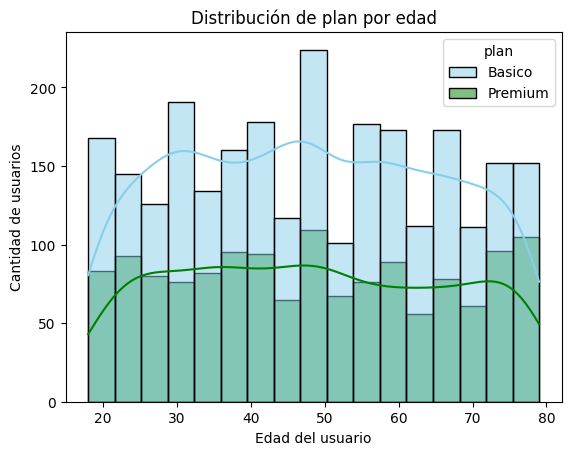

In [33]:
# Histograma para visualizar la edad (age)
sns.histplot(data=user_profile, x="age", hue="plan", palette=['skyblue','green'], kde=True)
plt.xlabel('Edad del usuario')
plt.ylabel('Cantidad de usuarios')
plt.title('Distribución de plan por edad')
plt.show()

💡Insights: 
- Distribución de alta dispersión, no se encuentra una desviación marcada hacia ninguno de los extremos, los usuarios se encuentran dispersos en todo el rango de edad, con una mayor concentración entre los 46 y los 51 años. Tanto el plan básico como el premium muestran distribuciones similares, con una mayor cantidad de usuarios totales en el plan básico.

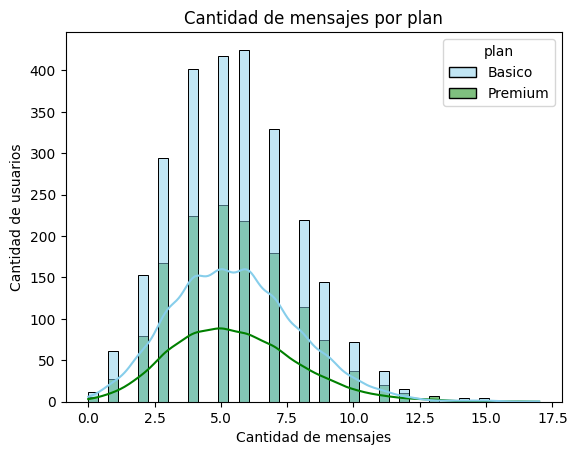

In [34]:
# Histograma para visualizar la cant_mensajes
sns.histplot(data=user_profile, x="cant_mensajes", hue="plan", palette=['skyblue','green'], kde=True)
plt.xlabel('Cantidad de mensajes')
plt.ylabel('Cantidad de usuarios')
plt.title('Cantidad de mensajes por plan')
plt.show()

💡Insights: 
- En cuanto a la cantidad de mensajes por usuario, tenemos una concentración notoria entre los 2.5 y los 10 mensajes por usuario, con picos entre las 5 y 6 unidades. Se presenta un sesgo a la derecha demostrando haber unos pocos usuarios que envían por encima de 12.5 mensajes. Nuevamente vemos distribución similar para ambos tipos de plan, teniendo mayor cantidad de usuarios totales el plan básico.

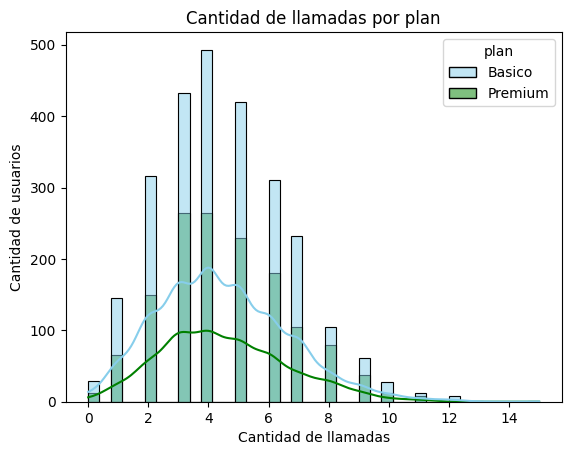

In [35]:
# Histograma para visualizar la cant_llamadas
sns.histplot(data=user_profile, x="cant_llamadas", hue="plan", palette=['skyblue','green'], kde=True)
plt.xlabel('Cantidad de llamadas')
plt.ylabel('Cantidad de usuarios')
plt.title('Cantidad de llamadas por plan')
plt.show()

💡Insights: 
- Para la cantidad de llamadas, vemos una distribución similar al caso de los mensajes, con una desviación a la derecha mostrando pocos usuarios que realizan de 10 llamadas en adelante, pero concentrando la mayoría del peso entre las 2 y las 6 llamadas, con un promedio de 4.4 llamadas por usuario y sin una diferencia significativa en la distribución de ambos planes. 

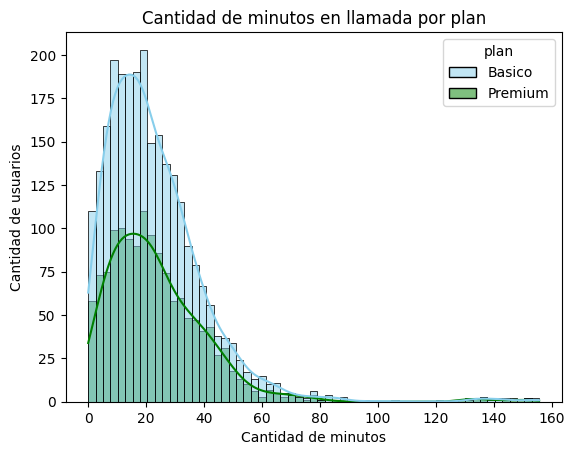

In [36]:
# Histograma para visualizar la cant_minutos_llamada
sns.histplot(data=user_profile, x="cant_minutos_llamada", hue="plan", palette=['skyblue','green'], kde=True)
plt.xlabel('Cantidad de minutos')
plt.ylabel('Cantidad de usuarios')
plt.title('Cantidad de minutos en llamada por plan')
plt.show()

💡Insights: 
- En cuanto a la cantidad de minutos por llamada, vemos una desviación significativamente sesgada a la derecha, concentrando la mayor parte de los datos por debajo de los 30 minutos, con un promedio de 23 minutos por llamada, y casos excepcionales que presentan máximos de hasta 155 minutos por llamada. Nuevamente vemos el mismo tipo de distribución para ambos planes, solo diferenciándose en la cantidad de usuarios totales.

### 5.2 Identificación de Outliers

🎯 **Objetivo:**  
Detectar valores extremos en las variables clave de **uso** y **clientes** que podrían afectar el análisis, y decidir si requieren limpieza o revisión adicional.

**Instrucciones:**  
- Usa **boxplots** para identificar visualmente outliers en las siguientes columnas:  
  - `age` 
  - `cant_mensajes`
  - `cant_llamadas`
  - `total_minutos_llamada`  
- Crea un **for** para generar los 4 boxplots automáticamente.
<br>

- Después de crear los gráfico, responde si **existen o no outliers** en las variables.  
- Si hay outliers, crea otro bucle para calcular los límites de esas columnas usando el **método IQR** y decide qué hacer con ellos.
  - Si solamente hay outliers de un solo lado, no es necesario calcular ambos límites.

**Hint:**
- Dentro del bucle, usa `plt.title(f'Boxplot: {col}')` para que el título cambie acorde a la columna.

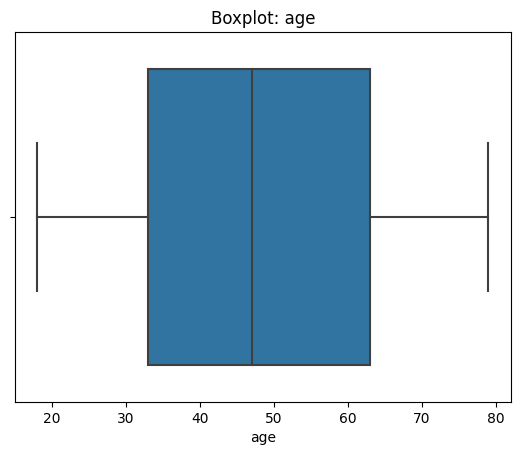

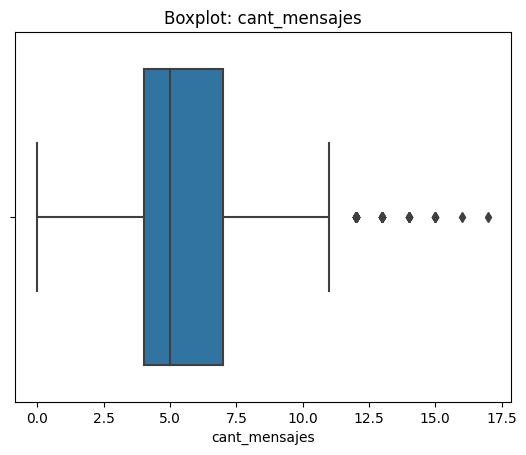

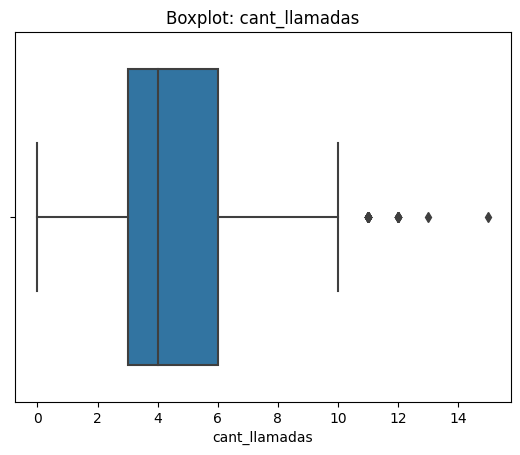

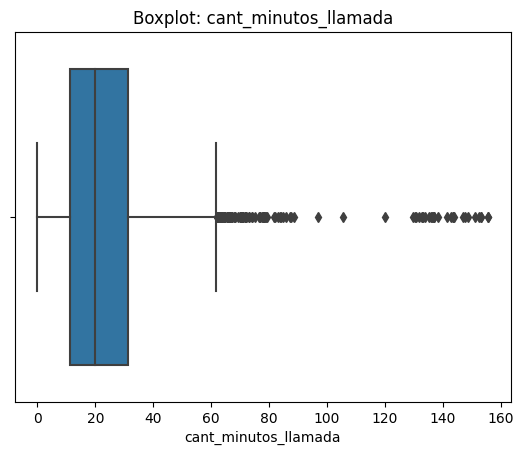

In [37]:
# Visualizando usando BoxPlot 
columnas_numericas = ['age', 'cant_mensajes', 'cant_llamadas', 'cant_minutos_llamada']

for col in columnas_numericas:
    sns.boxplot(data=user_profile, x=col)
    plt.title(f'Boxplot: {col}')
    plt.show()

💡Insights: 
- Age: no presenta outliers, presenta un rango amplio
- cant_mensajes: presenta outliers dispersos a la derecha del rango
- cant_llamadas: presenta un rango moderado, con outliers a la derecha del mismo y un caso excepcional muy por encima de la mediana
- cant_minutos_llamada: presenta un rango estrecho mostrando concentración en la parte baja del rango, outliers dispersos a la derecha de los bigotes

In [38]:
# Calcular límites con el método IQR


columnas_limites = ['cant_mensajes', 'cant_llamadas', 'cant_minutos_llamada']
for col in columnas_limites:
    Q1 = user_profile[col].quantile(0.25)
    Q3 = user_profile[col].quantile(0.75)
    IQR = Q3 - Q1

    limite_inferior = Q1 - 1.5 * IQR
    limite_superior = Q3 + 1.5 * IQR

    print(f"--- Métricas para la columna: {col} ---")
    print('Primer cuartil (Q1): ', Q1)
    print('Tercer cuartil (Q3): ', Q3)
    print('IQR:                 ', IQR)
    print('Límite Inferior:     ', limite_inferior)
    print('Límite Superior:     ', limite_superior)
    print("\n") 

--- Métricas para la columna: cant_mensajes ---
Primer cuartil (Q1):  4.0
Tercer cuartil (Q3):  7.0
IQR:                  3.0
Límite Inferior:      -0.5
Límite Superior:      11.5


--- Métricas para la columna: cant_llamadas ---
Primer cuartil (Q1):  3.0
Tercer cuartil (Q3):  6.0
IQR:                  3.0
Límite Inferior:      -1.5
Límite Superior:      10.5


--- Métricas para la columna: cant_minutos_llamada ---
Primer cuartil (Q1):  11.12
Tercer cuartil (Q3):  31.415
IQR:                  20.295
Límite Inferior:      -19.322500000000005
Límite Superior:      61.8575




In [39]:
# Revisa los limites superiores y el max, para tomar la decisión de mantener los outliers o no
user_profile[columnas_limites].describe()

,cant_mensajes,cant_llamadas,cant_minutos_llamada
count,3999.000000,3999.000000,3999.000000
mean,5.524381,4.478120,23.317054
std,2.358416,2.144238,18.168095
min,0.000000,0.000000,0.000000
25%,4.000000,3.000000,11.120000
50%,5.000000,4.000000,19.780000
75%,7.000000,6.000000,31.415000
max,17.000000,15.000000,155.690000


💡Insights: 
- cant_mensajes: mantener o no outliers, porqué?
Se recomienda hacer un windsor ya que los outliers están lo suficientemente lejos de la mediana como para afectar la media (media mayor que mediana) y no se presenta gran cantidad de registros en esas zonas máximas
- cant_llamadas: mantener o no outliers, porqué?
Se recomienda hacer un windsor ya que los outliers están lo suficientemente lejos de la mediana como para afectar la media (media mayor que mediana) y no se presenta gran cantidad de registros en esas zonas máximas
- cant_minutos_llamada: mantener o no outliers, porqué?
Se recomienda mantener los outliers y manejarlos especialmente para no perder segmentación, esto debido a que son bastantes los datos que se esparcen por encima del límite máximo, y pueden llegar a identificarse como clientes de alto consumo al no ser casos tan aislados

---

## 🧩Paso 6: Segmentación de Clientes

### 6.1 Segmentación de Clientes Por Uso

🎯 **Objetivo:** Clasificar a cada usuario en un grupo de uso (Bajo uso, Uso medio, Alto uso) basándose en la cantidad de llamadas y mensajes registrados.

**Instrucciones:**  
- Crea una nueva columna llamada `grupo_uso` en el dataframe `user_profile`.
- Usa comparaciones lógicas (<, >) para evaluar las condiciones de llamadas y mensajes y asigna:
  - `'Bajo uso'` cuando llamadas < 5 y mensajes < 5
  - `'Uso medio'` cuando llamadas < 10 y mensajes < 10
  - `'Alto uso'` para el resto de casos

In [53]:
# Crear columna grupo_uso
def determinar_grupo(row):

    if row["cant_mensajes"] < 5 and row["cant_llamadas"] < 5:
        return "Bajo uso"
    elif row["cant_mensajes"] < 10 and row["cant_llamadas"] < 10:
        return "Uso medio"
    else:
        return "Alto uso"

user_profile["grupo_uso"] = user_profile.apply(determinar_grupo, axis=1)

In [58]:
# verificar cambios
user_profile.head()
#user_profile["grupo_uso"].value_counts(normalize=True)

,user_id,cant_mensajes,cant_llamadas,cant_minutos_llamada,first_name,last_name,age,city,reg_date,plan,churn_date,grupo_uso,grupo_edad
0,10000,7,3,23.70,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,Uso medio,Adulto
1,10001,5,10,33.18,Mateo,Torres,53.0,NaN,2022-01-01 06:34:17.914478619,Basico,NaN,Alto uso,Adulto
2,10002,5,2,10.74,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,Uso medio,Adulto
3,10003,11,3,8.99,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,Alto uso,Adulto Mayor
4,10004,4,3,8.01,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,Bajo uso,Adulto Mayor


### 6.2 Segmentación de Clientes Por Edad

🎯 **Objetivo:**: Clasificar a cada usuario en un grupo por **edad**.

**Instrucciones:**  
- Crea una nueva columna llamada `grupo_edad` en el dataframe `user_profile`.
- Usa comparaciones lógicas (<, >) para evaluar las condiciones y asigna:
  - `'Joven'` cuando age < 30
  - `'Adulto'` cuando age < 60
  - `'Adulto Mayor'` para el resto de casos

In [42]:
# Crear columna grupo_edad

def determinar_grupo_edad(user_profile):
    
    if user_profile["age"] < 30:
        return "Joven"
    elif user_profile["age"] < 60:
        return "Adulto"
    else:
        return "Adulto Mayor"

user_profile["grupo_edad"] = user_profile.apply(determinar_grupo_edad, axis=1)

In [57]:
# verificar cambios
user_profile.head()
#user_profile["grupo_edad"].value_counts(normalize=True)

,user_id,cant_mensajes,cant_llamadas,cant_minutos_llamada,first_name,last_name,age,city,reg_date,plan,churn_date,grupo_uso,grupo_edad
0,10000,7,3,23.70,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,Uso medio,Adulto
1,10001,5,10,33.18,Mateo,Torres,53.0,NaN,2022-01-01 06:34:17.914478619,Basico,NaN,Alto uso,Adulto
2,10002,5,2,10.74,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,Uso medio,Adulto
3,10003,11,3,8.99,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,Alto uso,Adulto Mayor
4,10004,4,3,8.01,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,Bajo uso,Adulto Mayor


### 6.3 Visualización de la Segmentación de Clientes

🎯 **Objetivo:** Visualizar la distribución de los usuarios según los grupos creados: **grupo_uso** y **grupo_edad**.

**Instrucciones:**  
- Crea dos gráficos para las variables categóricas `grupo_uso` y `grupo_edad`.
- Agrega título y etiquetas a los ejes en cada gráfico.

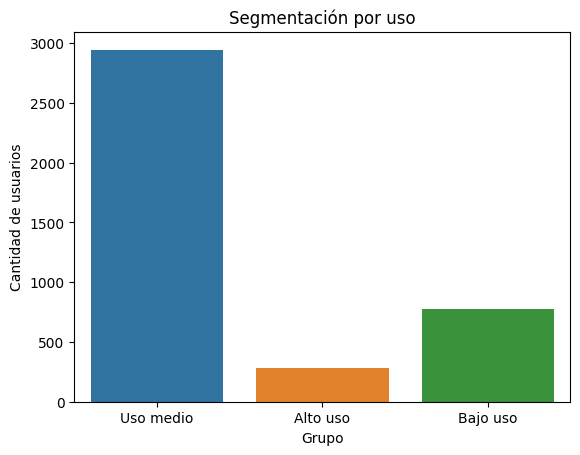

In [56]:
# Visualización de los segmentos por uso
sns.countplot(data=user_profile, x="grupo_uso")
plt.xlabel('Grupo')
plt.ylabel('Cantidad de usuarios')
plt.title('Segmentación por uso')
plt.show()

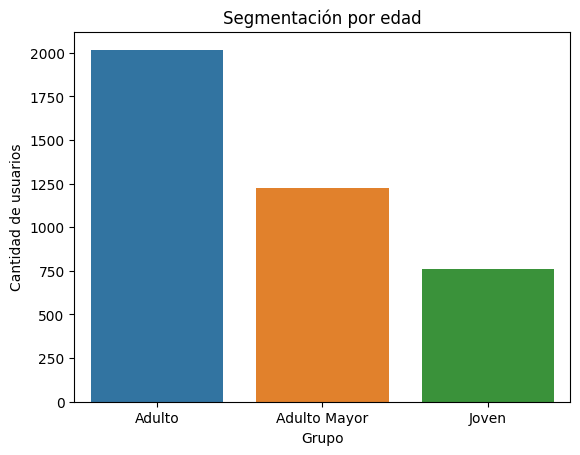

In [78]:
# Visualización de los segmentos por edad
sns.countplot(data=user_profile, x="grupo_edad")
plt.xlabel('Grupo')
plt.ylabel('Cantidad de usuarios')
plt.title('Segmentación por edad')
plt.show()


---
## 🧩Paso 7: Insight Ejecutivo para Stakeholders

🎯 **Objetivo:** Traducir los hallazgos del análisis en conclusiones accionables para el negocio, enfocadas en segmentación, patrones de uso y oportunidades comerciales.

**Preguntas a responder:** 
- ¿Qué problemas tenían originalmemte los datos?¿Qué porcentaje, o cantidad de filas, de esa columna representaban?


- ¿Qué segmentos de clientes identificaste y cómo se comportan según su edad y nivel de uso?  
- ¿Qué segmentos parecen más valiosos para ConnectaTel y por qué?  
- ¿Qué patrones de uso extremo (outliers) encontraste y qué implican para el negocio?


- ¿Qué recomendaciones harías para mejorar la oferta actual de planes o crear nuevos planes basados en los segmentos y patrones detectados?

✍️ **Escribe aquí tu análisis ejecutivo:**

### Análisis ejecutivo

⚠️ **Problemas detectados en los datos**
- El 11,7% de los usuarios no completan el campo de "Ciudad" en su registro
- No hay datos para usuarios registrados en el año 2025, pero sí para el 2026 que es un año inconcluso. Afortunadamente, los datos del 2026 representan apenas el 1% del total.

🔍 **Segmentos por Edad**
- El 50,4% de los usuarios registrados está en el segmento de "Adulto" entre los 30 y los 59 años
- El 30,5% de los usuarios registrados está en el segmento de "Adulto mayor" con 60 años o más
- El 19% de los usuarios registrados está en el segmento de "Joven" con menos de 30 años


📊 **Segmentos por Nivel de Uso**
- El 73,5% de los usuarios tiene un "Uso medio" teniendo entre 5 y 10 llamadas y/o mensajes de texto
- El 19,4% de los usuarios tiene un "Bajo uso" teniendo menos de 5 llamadas y/o mensajes de texto
- El 6,9% de los usuarios tiene un "Alto uso" teniendo más de 10 llamadas y/o mensajes de texto

➡️ Esto sugiere que más de la mitad de los usuarios registrados son adultos, con edades entre 30 y 59 años. A su vez, casi 3 cuartas partes (73,5%) de los usuarios realizaron entre 5 y 10 llamadas y/o mensaje desde su fecha de registro, aunque esta métrica puede verse relacionada con la antiguedad del usuario pues no se divide por periodos equitativos.


💡 **Recomendaciones**
- Enfocar las campañas al público de mediana edad (30-59) y al uso medio del plan
- Hacer un análisis anual o semestral con base en los segmentos creados para entender realmente el uso de cada usuario en lapsos equitativos.
- Asegurar el pleno registro demográfico de cada usuario para no perder datos importantes como la ciudad de residencia. 

---

## 🧩Paso 8 Cargar tu notebook y README a GitHub

🎯 **Objetivo:**  
Entregar tu análisis de forma **profesional**, **documentada** y **versionada**, asegurando que cualquier persona pueda revisar, ejecutar y entender tu trabajo.



### Opción A : Subir archivos desde la interfaz de GitHub (UI)

1. Descarga este notebook (`File → Download .ipynb`).  
2. Entra a tu repositorio en GitHub (por ejemplo `telecom-analysis` o `sprint7-final-project`).  
3. Sube tu notebook **Add file → Upload files**.  

---

### Opción B : Guardar directo desde Google Colab

1. Abre tu notebook en Colab.  
2. Ve a **File → Save a copy in GitHub**.  
3. Selecciona el repositorio y la carpeta correcta (ej: `notebooks/`).  
4. Escribe un mensaje de commit claro, por ejemplo:  
    - `feat: add final ConnectaTel analysis`
    - `agregar version final: Análisis ConnectaTel`
5. Verifica en GitHub que el archivo quedó en el lugar correcto y que el historial de commits se mantenga limpio.

---

Agrega un archivo `README.md` que describa de forma clara:
- el objetivo del proyecto,  
- los datasets utilizados,  
- las etapas del análisis realizadas,  
- cómo ejecutar el notebook (por ejemplo, abrirlo en Google Colab),  
- una breve guía de reproducción.
---

Link a repositorio público del proyecto: `LINK a tu repo aquí`